In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")

In [ ]:
##module 3

In [3]:
df["Queue"] = df["Team"].str.replace("Team", "Queue", regex=False)

In [4]:
queue_map = {
    "Software Support Team": "Software Queue",
    "Hardware Support Team": "Hardware Queue",
    "Network Support Team": "Network Queue",
    "Database Team": "Database Queue",
    "Security Team": "Security Queue"
}

df["Queue"] = df["Team"].map(queue_map)

## Ticket Type Distribution

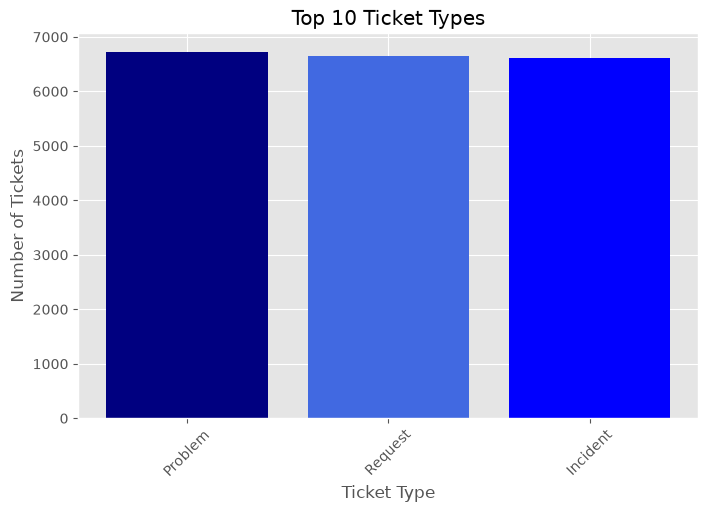

In [7]:
ticket_type=df["Ticket_Type"].value_counts().head(10)

plt.figure(figsize=(8,5))

colors=["navy","royalblue","blue","dodgerblue","deepskyblue","skyblue","lightskyblue","lightsteelblue","powderblue","lightcyan"]

plt.bar(ticket_type.index,ticket_type.values,color=colors)

plt.title("Top 10 Ticket Types")
plt.xlabel("Ticket Type")
plt.ylabel("Number of Tickets")

plt.xticks(rotation=45)

plt.show()

## Top Categories by Frequency

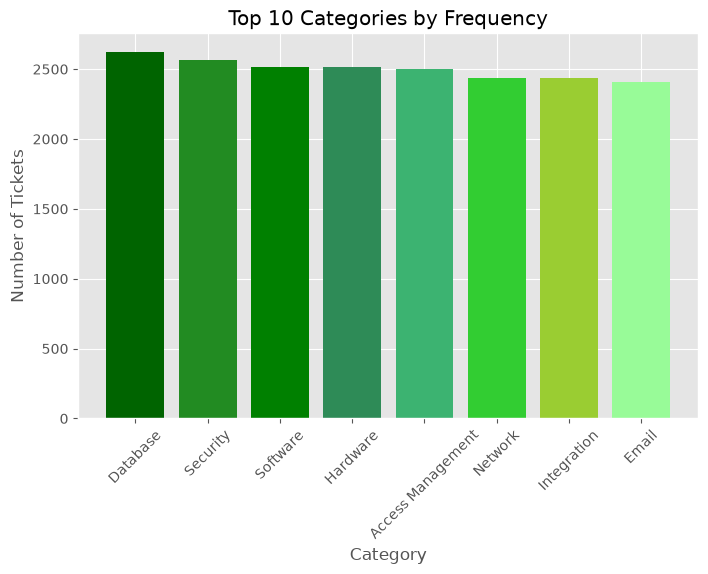

In [9]:
category=df["Category"].value_counts().head(10)
plt.figure(figsize=(8,5))
colors=["darkgreen","forestgreen","green","seagreen","mediumseagreen","limegreen","yellowgreen","palegreen","lightgreen","honeydew"]
plt.bar(category.index,category.values,color=colors)
plt.title("Top 10 Categories by Frequency")
plt.xlabel("Category")
plt.ylabel("Number of Tickets")
plt.xticks(rotation=45)
plt.show()

## Top Clusters by Frequency

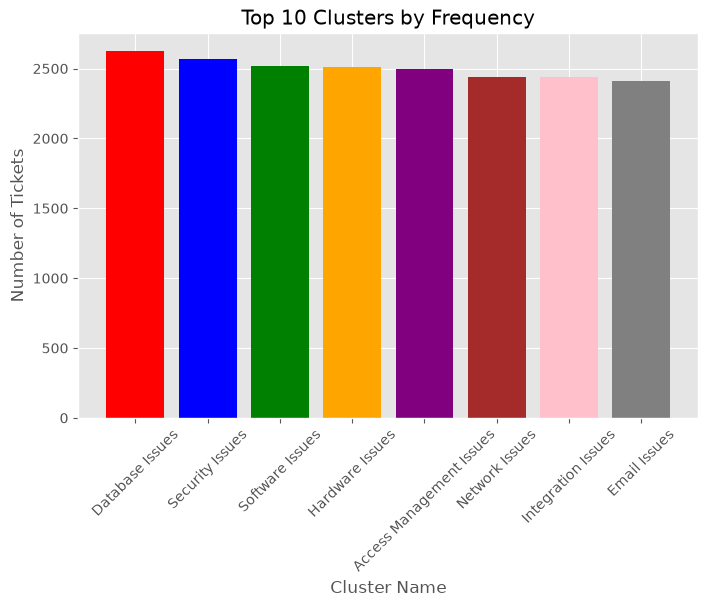

In [10]:
cluster = df["Cluster_Name"].value_counts().head(10)
plt.figure(figsize=(8,5))
colors = [
    "red", "blue", "green", "orange", "purple",
    "brown", "pink", "gray", "olive", "cyan"
]
plt.bar(cluster.index, cluster.values, color=colors)
plt.title("Top 10 Clusters by Frequency")
plt.xlabel("Cluster Name")
plt.ylabel("Number of Tickets")
plt.xticks(rotation=45)
plt.show()

## Tickets by Priority

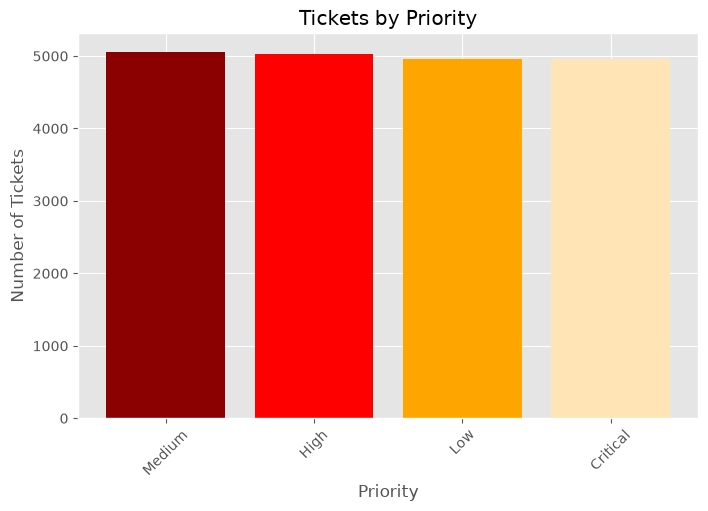

In [11]:
priority=df["Priority"].value_counts()

plt.figure(figsize=(8,5))

colors=["darkred","red","orange","moccasin"]

plt.bar(priority.index,priority.values,color=colors)

plt.title("Tickets by Priority")
plt.xlabel("Priority")
plt.ylabel("Number of Tickets")

plt.xticks(rotation=45)

plt.show()

## Tickets by Queue

In [13]:
queue = df["Queue"].value_counts().head(10)

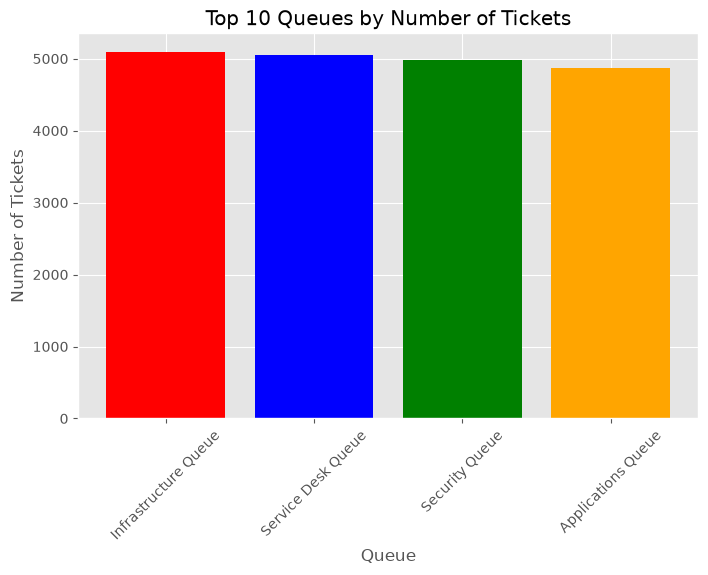

In [14]:
df["Queue"] = df["Team"] + " Queue"
queue = df["Queue"].value_counts().head(10)
plt.figure(figsize=(8,5))
colors = [
    "red", "blue", "green", "orange", "purple",
    "brown", "pink", "gray", "olive", "cyan"
]
plt.bar(queue.index, queue.values, color=colors)
plt.title("Top 10 Queues by Number of Tickets")
plt.xlabel("Queue")
plt.ylabel("Number of Tickets")
plt.xticks(rotation=45)
plt.show()

MODULE 4|

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
df = pd.read_excel("Supportlytics_Processed_Data.xlsx")

In [5]:
df["Cluster"] = df["Team"]
df[["Team", "Cluster"]].head()

,Team,Cluster
0,Security,Security
1,Security,Security
2,Security,Security
3,Applications,Applications
4,Applications,Applications


In [6]:
max_duration = df["Resolution_Duration"].max()

df["Similarity_Score"] = (
    1 - (df["Resolution_Duration"] / max_duration)
).round(2)
df[["Resolution_Duration", "Similarity_Score"]].head()

,Resolution_Duration,Similarity_Score
0,3,0.75
1,0,1.00
2,2,0.83
3,2,0.83
4,4,0.67


In [4]:

df.to_excel("Supportlytics_Processed_Data.xlsx", index=False)


In [8]:
cluster_similarity = df.groupby("Cluster")["Similarity_Score"].mean().sort_values(ascending=False)
print(cluster_similarity)

Cluster
Applications      0.743215
Security          0.738408
Infrastructure    0.738210
Service Desk      0.737559
Name: Similarity_Score, dtype: float64


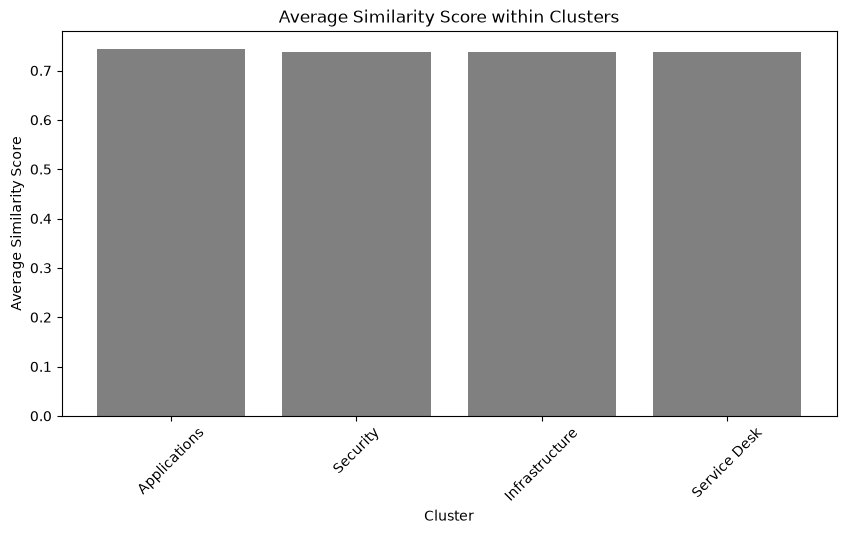

In [11]:
plt.figure(figsize=(10,5))
plt.bar(
    cluster_similarity.index,
    cluster_similarity.values,
    color="gray"
)
plt.title("Average Similarity Score within Clusters")
plt.xlabel("Cluster")
plt.ylabel("Average Similarity Score")
plt.xticks(rotation=45)
plt.show()

In [12]:
cluster_issue = pd.crosstab(df["Cluster"], df["Ticket_Type"])
cluster_issue

Ticket_Type,Incident,Problem,Request
Cluster,,,
Applications,1611,1626,1634
Infrastructure,1614,1763,1718
Security,1645,1670,1667
Service Desk,1747,1671,1634


<Figure size 1200x600 with 0 Axes>

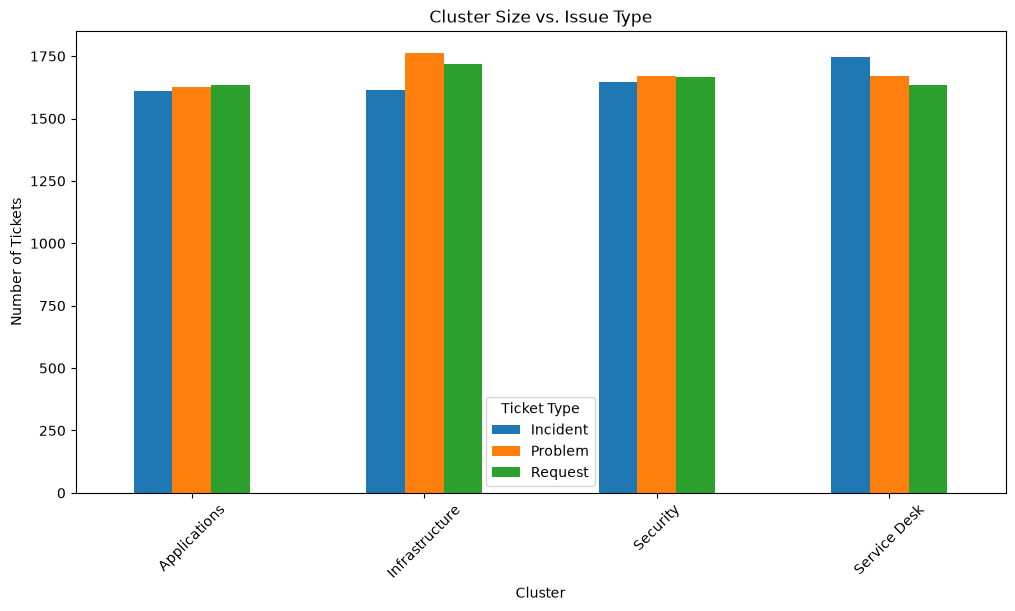

In [13]:
plt.figure(figsize=(12,6))

cluster_issue.plot(
    kind="bar",
    figsize=(12,6)
)

plt.title("Cluster Size vs. Issue Type")
plt.xlabel("Cluster")
plt.ylabel("Number of Tickets")

plt.xticks(rotation=45)

plt.legend(title="Ticket Type")

plt.show()

Boxplot of Similarity Score by Cluster

<Figure size 1000x600 with 0 Axes>

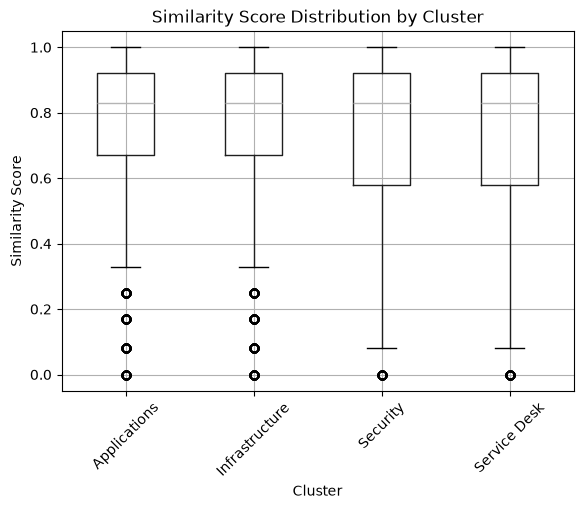

In [20]:
plt.figure(figsize=(10,6))

df.boxplot(
    column="Similarity_Score",
    by="Cluster"
)

plt.title("Similarity Score Distribution by Cluster")
plt.suptitle("")
plt.xlabel("Cluster")
plt.ylabel("Similarity Score")

plt.xticks(rotation=45)

plt.show()

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
df = pd.read_excel("Supportlytics_Processed_Data.xlsx")
df.head()

,Ticket_ID,Created_Date,Resolution_Date,Status,Priority,Ticket_Type,Category,Country,Cluster_ID,Cluster_Name,...,Product,Customer_Satisfaction,Escalation_Level,Region,Device_Type,Operating_System,Resolution_Notes,Resolution_Duration,Priority_score,Cluster
0,TKT000001,2025-04-14 22:00:00,2025-04-17 22:00:00,Open,Medium,Request,Network,USA,1,Network Issues,...,VPN,3,L2,North America,Mobile,RHEL,Resolved after troubleshooting network.,3,2,Security
1,TKT000002,2026-03-30 02:00:00,2026-03-30 02:00:00,Resolved,Low,Problem,Software,UAE,2,Software Issues,...,ServiceNow,2,L3,North America,Mobile,Ubuntu,Resolved after troubleshooting software.,0,1,Security
2,TKT000003,2025-06-13 21:00:00,2025-06-15 21:00:00,Closed,Critical,Request,Software,USA,2,Software Issues,...,ServiceNow,5,L3,Europe,Mobile,Ubuntu,Resolved after troubleshooting software.,2,4,Security
3,TKT000004,2025-03-22 01:00:00,2025-03-24 01:00:00,Resolved,High,Incident,Email,India,7,Email Issues,...,SAP,2,L3,Europe,Laptop,Windows 11,Resolved after troubleshooting email.,2,3,Applications
4,TKT000005,2025-01-14 11:00:00,2025-01-18 11:00:00,Resolved,High,Request,Access Management,Canada,8,Access Management Issues,...,SAP,4,L1,North America,Server,RHEL,Resolved after troubleshooting access management.,4,3,Applications


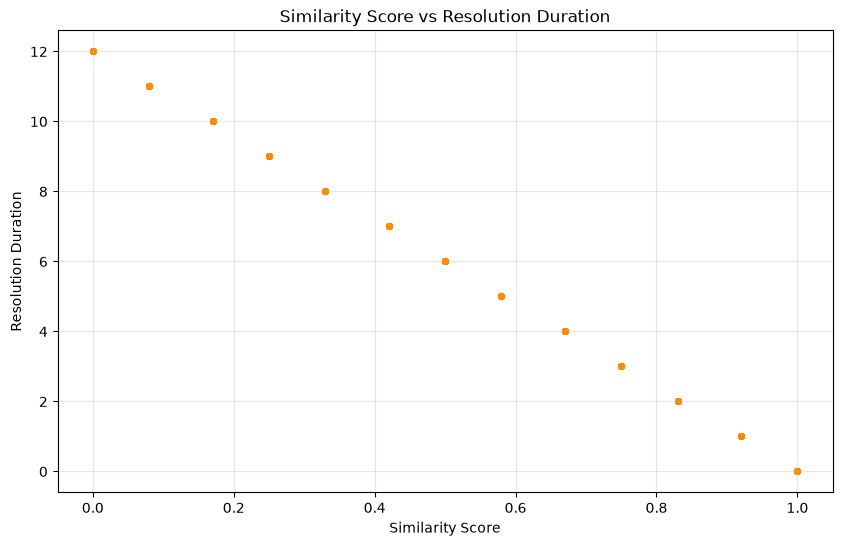

In [6]:
plt.figure(figsize=(10,6))

plt.scatter(
    df["Similarity_Score"],
    df["Resolution_Duration"],
    color="darkorange",
    alpha=0.6,
    s=15
)
plt.title("Similarity Score vs Resolution Duration")
plt.xlabel("Similarity Score")
plt.ylabel("Resolution Duration")
plt.grid(alpha=0.3)
plt.show()

Visualization 5: Average Similarity Score by Ticket Type

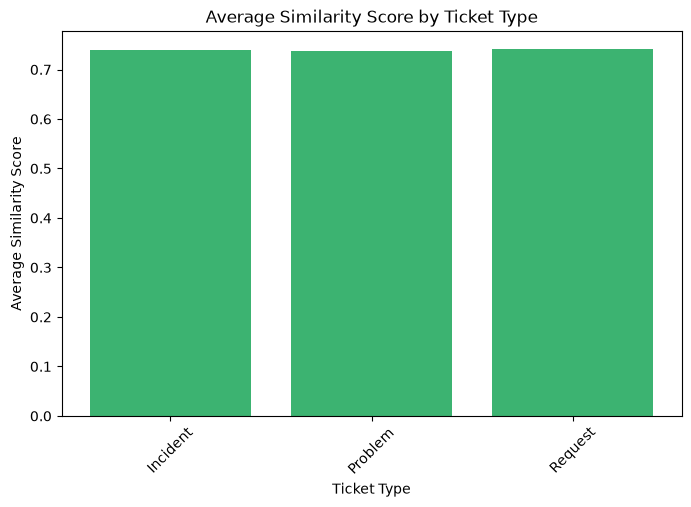

In [24]:
ticket_similarity = df.groupby("Ticket_Type")["Similarity_Score"].mean()

plt.figure(figsize=(8,5))

plt.bar(
    ticket_similarity.index,
    ticket_similarity.values,
    color="mediumseagreen"
)

plt.title("Average Similarity Score by Ticket Type")
plt.xlabel("Ticket Type")
plt.ylabel("Average Similarity Score")

plt.xticks(rotation=45)

plt.show()

 Number of Tickets in Each Cluster

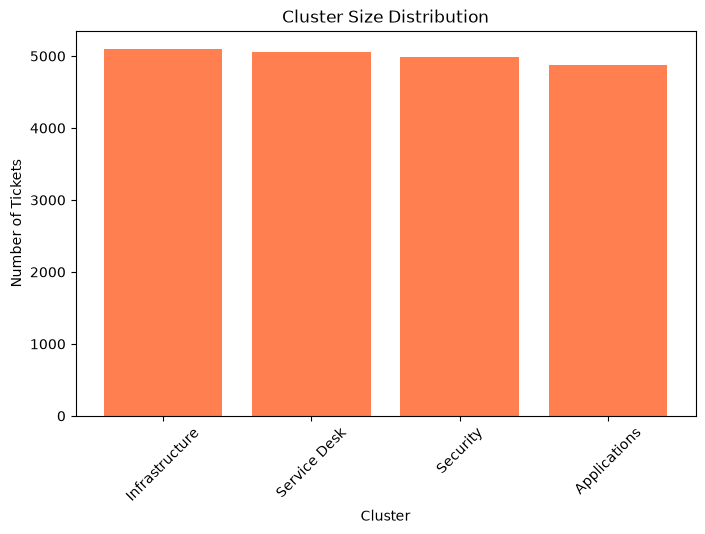

In [25]:
cluster_size = df["Cluster"].value_counts()

plt.figure(figsize=(8,5))

plt.bar(
    cluster_size.index,
    cluster_size.values,
    color="coral"
)

plt.title("Cluster Size Distribution")
plt.xlabel("Cluster")
plt.ylabel("Number of Tickets")

plt.xticks(rotation=45)

plt.show()

Average Customer Satisfaction by Cluster

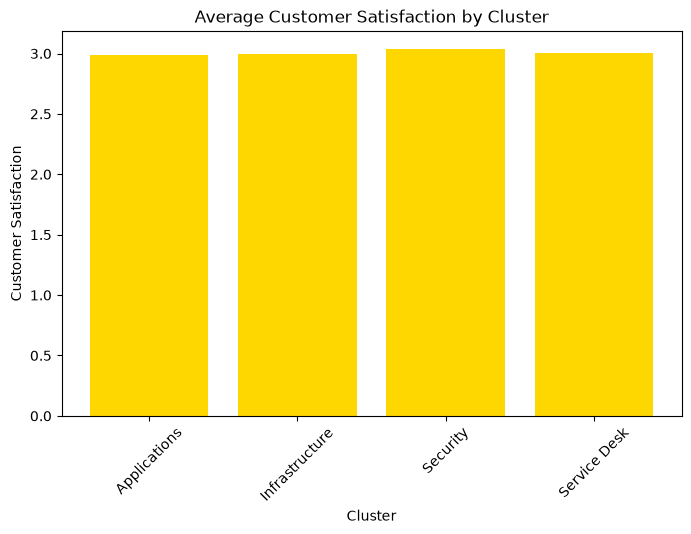

In [26]:
cluster_csat = df.groupby("Cluster")["Customer_Satisfaction"].mean()

plt.figure(figsize=(8,5))

plt.bar(
    cluster_csat.index,
    cluster_csat.values,
    color="gold"
)

plt.title("Average Customer Satisfaction by Cluster")
plt.xlabel("Cluster")
plt.ylabel("Customer Satisfaction")

plt.xticks(rotation=45)

plt.show()

Priority Distribution Across Clusters

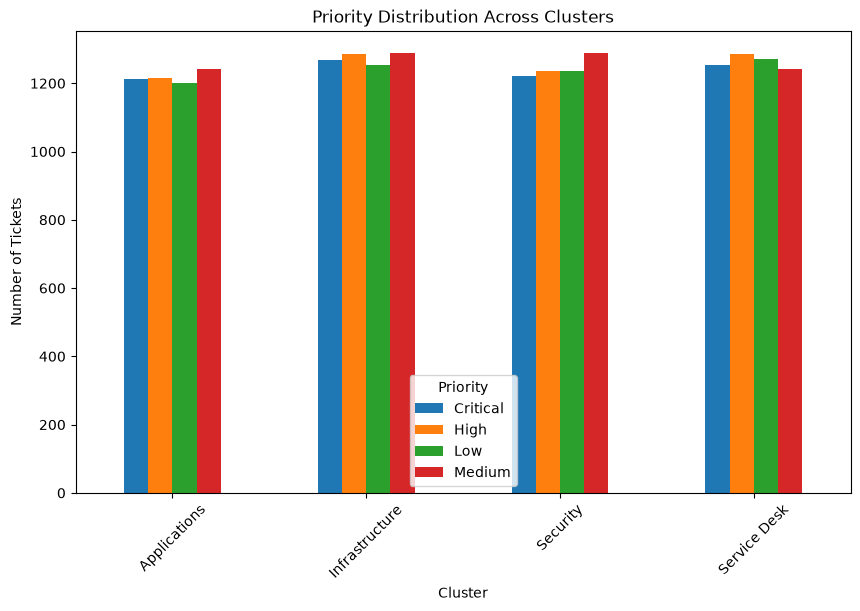

In [27]:
priority_cluster = pd.crosstab(df["Cluster"], df["Priority"])

priority_cluster.plot(
    kind="bar",
    figsize=(10,6)
)

plt.title("Priority Distribution Across Clusters")
plt.xlabel("Cluster")
plt.ylabel("Number of Tickets")

plt.xticks(rotation=45)

plt.legend(title="Priority")

plt.show()